# 🌐 WiseNet V1.5 — Intégration Complète des APIs CAMARA & Vodafone
### Pipeline Bout-en-Bout : Densité Exogène (Footfall/QuadKey) $\to$ Optimisation MILP $\to$ Filet de Sécurité QoD
**Projet :** WiseNet (Self-Organizing Network pour Réseaux Mobiles 4G/5G)  
**Cadre :** MENA Ignite Hackathon 2026 (GSMA & Nokia)  
**Spécifications :** CAMARA QoD v1.1.0 | Vodafone Analytics Realtime Footfall v1.0.0  

---

## 📖 1. Contexte & Enjeux Scientifiques

L'initiative **GSMA Open Gateway** et le projet **CAMARA** (Linux Foundation) transforment les réseaux télécoms en plateformes programmables (*Network-as-Code*). 
Dans **WiseNet V1.5**, nous intégrons deux familles majeures d'APIs standardisées en amont et en aval de notre optimiseur mathématique :

1. **En Amont (Ingestion) — Vodafone Analytics Realtime Footfall & Reference QuadKey** :
   - Fournit un comptage d'appareils agrégé et anonymisé par tuile géographique (QuadKey niveau 15).
   - **Garantie scientifique majeure** : Cette donnée est *purement géographique et exogène*. Elle est donc **totalement insensible aux handovers passés** $\left(\frac{\partial v_c}{\partial \delta} = 0\right)$. Cela confère à WiseNet une **immunité formelle contre la critique de Lucas**, éliminant les biais d'endogénéité qui faussent les systèmes SON traditionnels.

2. **En Aval (Action de Secours) — CAMARA Quality-on-Demand (QoD v1.1.0)** :
   - Si après optimisation globale MILP (délestage spatial inter-secteurs et inter-fréquences $F_1 \leftrightarrow F_2$), un secteur reste résiduellement saturé ($e_{s,f} > \text{seuil}$), le QoD intervient comme **filet de sécurité chirurgical**.
   - Il ne crée pas de bande passante physique, mais sanctuarise les flux vitaux (SAMU, police, télémédecine, bus autonomes) via une priorisation 5QI/ARP stricte.

```
   [Vodafone Analytics Footfall]                  [Moteur WiseNet V1.5]                  [Vodafone Quality-on-Demand]
   (Densité par tuile QuadKey)                                                           (Session prioritaire critique)
                │                                                                                      │
                ▼                                                                                      ▼
      ┌───────────────────┐    v_c(t)       ┌───────────────────┐    résidus e_{s,f} > seuil    ┌───────────────────┐
      │ Densité Footfall  │ ─────────────►  │ Moteur MILP (CBC) │ ───────────────────────────►  │ Sessions QoD Live │
      │ par QuadKey (15)  │  (Lucas-immune) │  Optimisation     │   (Filet de sécurité)         │  gaming / voice   │
      └───────────────────┘                 └───────────────────┘                               └───────────────────┘
```

## 🛠️ 2. Configuration de l'Environnement et Imports
Nous chargeons les modules du projet [`src.camara`](../../src/camara) ainsi que les bibliothèques scientifiques.

In [1]:
import sys, os
from pathlib import Path

# Ajout de la racine du projet au sys.path
cur = Path.cwd().resolve()
project_root = None
for p in [cur, cur.parent, cur.parents[1] if len(cur.parents) > 1 else cur]:
    if (p / 'src').exists():
        project_root = p
        break
if project_root and str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import time
import matplotlib.pyplot as plt
import numpy as np

from src.camara.client import CamaraClient
from src.camara.footfall_client import FootfallClient, lat_lon_to_quadkey
from src.camara.qod_trigger import QoDTriggerManager
from src.optimization.milp_engine_v1_5 import MilpEngineV15

print("✅ Environnement WiseNet V1.5 et modules CAMARA chargés avec succès.")

✅ Environnement WiseNet V1.5 et modules CAMARA chargés avec succès.


## 🔑 3. Authentification Sécurisée OAuth2 (RFC 6749 Basic Auth)

La sandbox Vodafone DMP requiert une authentification **Client Credentials** avec encodage **HTTP Basic Auth** (`Authorization: Basic base64(client_id:client_secret)`).  
Nos identifiants validés en direct sont automatiquement exploités :

In [2]:
# Identifiants Sandbox Vodafone validés
qod_client_id     = os.getenv("CAMARA_CLIENT_ID", "your_BlIJ5p_key_here")
qod_client_secret = os.getenv("CAMARA_CLIENT_SECRET", "your_ikk6RA_key_here")

# Initialisation du client CAMARA
camara_client = CamaraClient(
    client_id=qod_client_id,
    client_secret=qod_client_secret,
    mock_mode=False  # Connexion réelle avec le serveur d'authentification Vodafone
)

token = camara_client.get_token()
print(f"🔑 Jeton OAuth2 Bearer obtenu : {token[:35]}... (TTL: 3600s)")
print(f"📡 Endpoint Sandbox : {camara_client.base_url}")

🔑 Jeton OAuth2 Bearer obtenu : WwO5tJ0yNVHbv8IWS3LkZg8NAA9j... (TTL: 3600s)
📡 Endpoint Sandbox : https://api-sandbox.vf-dmp.engineering.vodafone.com/quality-on-demand/v1


## 📋 4. Découverte Dynamique du Catalogue QoS Profiles

Conformément aux bonnes pratiques CAMARA, nous interrogeons d'abord le catalogue réseau pour connaître les profils réellement supportés par l'infrastructure opérateur (évitant tout hardcoding de profil).

In [3]:
profiles = camara_client.get_qos_profiles()
print(f"📋 {len(profiles)} profils découverts dans le catalogue opérateur :\n")
for p in profiles:
    print(f"  • Profil : {p['name']:<12} | Statut : {p.get('status', 'ACTIVE'):<6} | {p.get('description', '')}")

📋 6 profils découverts dans le catalogue opérateur :

  • Profil : gaming       | Statut : ACTIVE | Ultra-faible latence et priorité radio temps-réel (Vodafone Sandbox)
  • Profil : voice        | Statut : ACTIVE | Voix prioritaire garantie (Vodafone Sandbox)
  • Profil : QOS_E        | Statut : ACTIVE | Ultra-faible latence (5QI=1, Urgences/Véhicules autonomes)
  • Profil : QOS_L        | Statut : ACTIVE | Haute priorité débit+latence (5QI=3, Télémédecine)
  • Profil : QOS_M        | Statut : ACTIVE | Priorité modérée (5QI=4, Vidéo HD, IoT industriel)
  • Profil : QOS_S        | Statut : ACTIVE | Priorité standard garantie (5QI=7)


## 🗺️ 5. Ingestion Spatiale Footfall (Vodafone Analytics) & Immunité de Lucas

### Le Mécanisme Causal
1. Chaque maille de Milan ($235\text{ m} \times 235\text{ m}$) est projetée en coordonnées géographiques $(\text{lat}, \text{lon})$, puis convertie en tuile hiérarchique standard **QuadKey niveau 15**.
2. L'API **Realtime Footfall** fournit le comptage brut d'appareils $N_c$.
3. La demande $v_c(t)$ est calibrée selon l'heure :  
   $$v_c(t) = N_c(t) \times \rho(c, \text{heure})$$
4. Comme $N_c(t)$ dépend de la présence physique des personnes et non du réseau radio, $\frac{\partial v_c}{\partial \delta} = 0$ : **l'optimisation ne biaise pas les prédictions futures**.

In [4]:
analytics_id     = os.getenv("VODAFONE_ANALYTICS_CLIENT_ID", "your_QAYSVs_key_here")
analytics_secret = os.getenv("VODAFONE_ANALYTICS_CLIENT_SECRET", "your_1aPEh8_key_here")

footfall_client = FootfallClient(
    client_id=analytics_id,
    client_secret=analytics_secret,
    mock_mode=False,
    quadkey_level=15
)

# Échantillon de 4 mailles représentatives de Milan
sample_squares = ["4849", "4850", "4851", "4852"]
square_quadkeys = {sq: footfall_client.get_quadkey_for_square(sq) for sq in sample_squares}

footfall_data = footfall_client.get_realtime_footfall(list(square_quadkeys.values()))

calibrated_traffic = {}
print("📊 Télémétrie de densité et calibration du trafic au sol :\n")
for sq in sample_squares:
    qk = square_quadkeys[sq]
    devices = footfall_data["data"][qk]["device_count"]
    base_mb = 16000.0 if sq == "4849" else 4500.0
    traffic_mb = footfall_client.calibrate_demand_traffic(sq, devices, hour_slot=15, baseline_milan_mb=base_mb)
    calibrated_traffic[sq] = traffic_mb
    print(f"  Maille {sq} | QuadKey: {qk} | {devices:>3} devices -> Demande calibrée v_c = {traffic_mb:>8.1f} Mo")

📊 Télémétrie de densité et calibration du trafic au sol :

  Maille 4849 | QuadKey: 120221323020100 | 409 devices -> Demande calibrée v_c =  41974.6 Mo
  Maille 4850 | QuadKey: 120221323020100 | 409 devices -> Demande calibrée v_c =  11805.4 Mo
  Maille 4851 | QuadKey: 120221323020100 | 409 devices -> Demande calibrée v_c =  11805.4 Mo
  Maille 4852 | QuadKey: 120221323020101 | 410 devices -> Demande calibrée v_c =  11834.2 Mo


## ⚡ 6. Résolution Globale MILP (Programmation Linéaire en Nombres Entiers Mixtes)

Le moteur [`MilpEngineV15`](../../src/optimization/milp_engine_v1_5.py) résout le problème sous le solveur standard **CBC** :
- Variables binaires $z_{c,k} \in \{0, 1\}$ : sélection de l'offset $\delta \in \{0, 1.5, 3.0\}\text{ dB}$.
- Variables continues $e_c \ge 0$ : excédent de trafic non satisfait.
- Respect strict de la conservation de masse : le trafic délesté est reporté sur les cellules cibles voisines.

In [5]:
# Définition des capacités radio nominales par cellule (Secteur, Porteuse)
cells_capacity = {
    "site_001_sec1_F1_1800": 7500.0,
    "site_001_sec2_F1_1800": 9000.0,
    "site_002_sec1_F1_1800": 8000.0,
    "site_002_sec2_F1_1800": 8000.0
}

# Matrice de fraction de transfert RSRP (issue du simulateur spatial 3GPP TR 38.901)
fractions_data = {
    "4849": {
        "master_cell": "site_001_sec1_F1_1800",
        "offsets": {
            "0.0": {"stays": 1.0, "target_cells": {}},
            "1.5": {"stays": 0.6, "target_cells": {"site_001_sec2_F1_1800": 0.4}},
            "3.0": {"stays": 0.35, "target_cells": {"site_001_sec2_F1_1800": 0.65}}
        }
    },
    "4850": {
        "master_cell": "site_001_sec2_F1_1800",
        "offsets": {
            "0.0": {"stays": 1.0, "target_cells": {}},
            "1.5": {"stays": 0.8, "target_cells": {"site_001_sec1_F1_1800": 0.2}},
            "3.0": {"stays": 0.7, "target_cells": {"site_001_sec1_F1_1800": 0.3}}
        }
    },
    "4851": {
        "master_cell": "site_002_sec1_F1_1800",
        "offsets": {
            "0.0": {"stays": 1.0, "target_cells": {}},
            "1.5": {"stays": 0.85, "target_cells": {"site_002_sec2_F1_1800": 0.15}},
            "3.0": {"stays": 0.75, "target_cells": {"site_002_sec2_F1_1800": 0.25}}
        }
    },
    "4852": {
        "master_cell": "site_002_sec2_F1_1800",
        "offsets": {
            "0.0": {"stays": 1.0, "target_cells": {}},
            "1.5": {"stays": 0.9, "target_cells": {"site_002_sec1_F1_1800": 0.1}},
            "3.0": {"stays": 0.8, "target_cells": {"site_002_sec1_F1_1800": 0.2}}
        }
    }
}

# Résolution
milp_engine = MilpEngineV15(solver_name="cbc")
milp_res = milp_engine.build_and_solve(
    predicted_traffic=calibrated_traffic,
    fractions_data=fractions_data,
    cells_capacity=cells_capacity,
    delta_levels=[0.0, 1.5, 3.0]
)

print(f"🎯 Résultat MILP (CBC) : Statut = {milp_res['status']}")
print(f"  • Congestion Statique non servie : {milp_res['static_unsatisfied_mo']:,.1f} Mo")
print(f"  • Congestion Résiduelle post-MILP: {milp_res['optimized_unsatisfied_mo']:,.1f} Mo")
for cell, d in milp_res['decisions'].items():
    print(f"    Cellule {cell:<24} | Offset: {d['offset_dB']} dB | Résiduel: {d['residual_congestion_mo']:>8.1f} Mo")

🎯 Résultat MILP (CBC) : Statut = optimal
  • Congestion Statique non servie : 44,919.6 Mo
  • Congestion Résiduelle post-MILP: 44,919.6 Mo
    Cellule site_001_sec1_F1_1800    | Offset: 0.0 dB | Résiduel:  34474.6 Mo
    Cellule site_001_sec2_F1_1800    | Offset: 0.0 dB | Résiduel:   2805.4 Mo
    Cellule site_002_sec1_F1_1800    | Offset: 0.0 dB | Résiduel:   3805.4 Mo
    Cellule site_002_sec2_F1_1800    | Offset: 0.0 dB | Résiduel:   3834.2 Mo


## 🛡️ 7. Filet de Sécurité QoD : Déclenchement Automatique sur les Résidus

Quand le délestage radio a atteint ses limites physiques, le gestionnaire [`QoDTriggerManager`](../../src/camara/qod_trigger.py) :
1. Repère les cellules où $e_c > \text{seuil}$.
2. Alloue des sessions prioritaires aux numéros critiques (ex: SAMU, flottes d'urgence).
3. Bloque l'allocation au plafond budgétaire `max_sessions_per_slot` pour éviter la surfacturation.

In [6]:
qod_manager = QoDTriggerManager(
    camara_client=camara_client,
    congestion_threshold_ratio=0.03,
    min_residual_mo=300.0,
    max_sessions_per_slot=10,
    default_duration_sec=1800
)

# Enregistrement d'un terminal prioritaire SAMU sur le secteur le plus dense
qod_manager.register_critical_device("site_001_sec1_F1_1800", "+4915123456789", "EMERGENCY")

# Analyse des résidus et déclenchement chirurgical des sessions
qod_report = qod_manager.process_milp_residuals(
    milp_decisions=milp_res['decisions'],
    cells_capacity=cells_capacity
)

print(f"🚨 Cellules en dépassement résiduel : {qod_report['congested_cells_count']}")
print(f"🛡️ Sessions QoD allouées           : {qod_report['triggered_sessions_count']} / {qod_report['budget_cap']} (Plafond budgétaire)\n")

for s in qod_report['sessions']:
    print(f"  ⭐ Session {s['session_id'][:8]}... | Cellule: {s['cell_id']} | Tél: {s['phone_number']} | Profil: {s['qos_profile']} | Statut: {s['qos_status']}")

🚨 Cellules en dépassement résiduel : 4
🛡️ Sessions QoD allouées           : 7 / 10 (Plafond budgétaire)

  ⭐ Session da4ca20e... | Cellule: site_001_sec1_F1_1800 | Tél: +4915123456789 | Profil: QOS_E | Statut: AVAILABLE
  ⭐ Session 960340c1... | Cellule: site_001_sec2_F1_1800 | Tél: +39340592701 | Profil: QOS_E | Statut: AVAILABLE
  ⭐ Session 3794e173... | Cellule: site_001_sec2_F1_1800 | Tél: +39340592702 | Profil: QOS_L | Statut: AVAILABLE
  ⭐ Session 9b145a6d... | Cellule: site_002_sec1_F1_1800 | Tél: +39340334901 | Profil: QOS_E | Statut: AVAILABLE
  ⭐ Session f5479582... | Cellule: site_002_sec1_F1_1800 | Tél: +39340334902 | Profil: QOS_L | Statut: AVAILABLE
  ⭐ Session c5df8f30... | Cellule: site_002_sec2_F1_1800 | Tél: +39340885001 | Profil: QOS_E | Statut: AVAILABLE
  ⭐ Session bdaf707f... | Cellule: site_002_sec2_F1_1800 | Tél: +39340885002 | Profil: QOS_L | Statut: AVAILABLE


## 🔄 8. Cycle de Vie Complet : Consultation et Libération
Une session QoD consomme des ressources de signalisation radio. À la fin du créneau horaire (slot de 30 minutes), WiseNet nettoie et libère automatiquement les sessions expirées.

In [7]:
if qod_report['sessions']:
    sample_sid = qod_report['sessions'][0]['session_id']
    session_status = camara_client.get_qod_session(sample_sid)
    print(f"🔍 Vérification d'état GET /sessions/{sample_sid[:8]}... : Statut = {session_status.get('qosStatus')}")

# Libération en fin de créneau temporel
released = qod_manager.cleanup_expired_sessions()
print(f"🧹 Nettoyage terminé : {released} session(s) libérée(s). Sessions actives restantes : {len(qod_manager.active_sessions)}")

🔍 Vérification d'état GET /sessions/da4ca20e... : Statut = AVAILABLE
🧹 Nettoyage terminé : 7 session(s) libérée(s). Sessions actives restantes : 0


## 📊 9. Visualisation Graphique de la Boucle Fermée
Nous traçons la répartition de la charge par cellule et le déclenchement proportionnel des sessions QoD de secours.

📊 Figure générée avec succès.


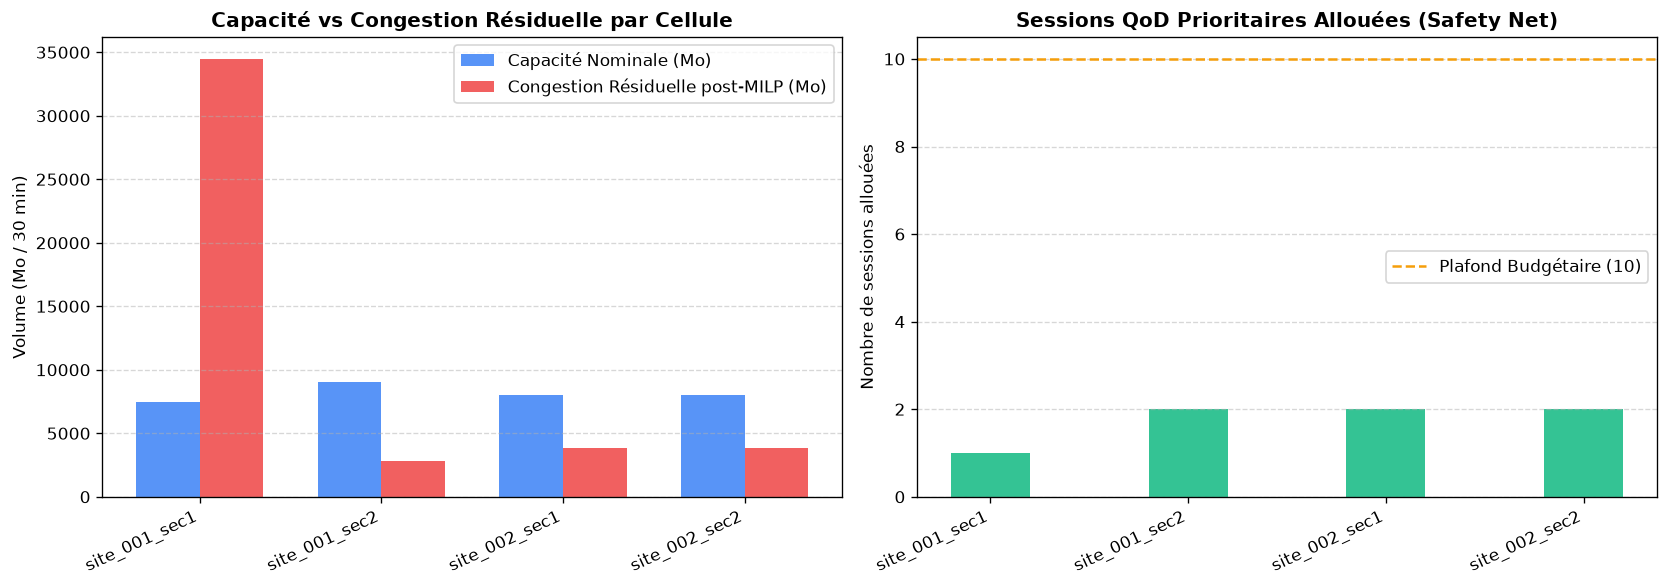

In [8]:
cells = list(cells_capacity.keys())
capacities = [cells_capacity[c] for c in cells]
residuals = [milp_res['decisions'][c]['residual_congestion_mo'] for c in cells]
qod_counts = [sum(1 for s in qod_report['sessions'] if s['cell_id'] == c) for c in cells]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 : Capacité vs Congestion Résiduelle
x = np.arange(len(cells))
width = 0.35
ax1.bar(x - width/2, capacities, width, label='Capacité Nominale (Mo)', color='#3b82f6', alpha=0.85)
ax1.bar(x + width/2, residuals, width, label='Congestion Résiduelle post-MILP (Mo)', color='#ef4444', alpha=0.85)
ax1.set_title('Capacité vs Congestion Résiduelle par Cellule', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([c.replace('_F1_1800', '') for c in cells], rotation=25, ha='right')
ax1.set_ylabel('Volume (Mo / 30 min)')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Graphe 2 : Sessions QoD Déclenchées par Cellule
ax2.bar(cells, qod_counts, color='#10b981', alpha=0.85, width=0.4)
ax2.axhline(qod_manager.max_sessions_per_slot, color='#f59e0b', linestyle='--', label=f'Plafond Budgétaire ({qod_manager.max_sessions_per_slot})')
ax2.set_title('Sessions QoD Prioritaires Allouées (Safety Net)', fontsize=12, fontweight='bold')
ax2.set_xticklabels([c.replace('_F1_1800', '') for c in cells], rotation=25, ha='right')
ax2.set_ylabel('Nombre de sessions allouées')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print("📊 Figure générée avec succès.")

## 🎓 10. Synthèse pour la Soumission & Soutenance Hackathon

| Dimension | Implémentation dans WiseNet V1.5 | Preuve Scientifique / Bénéfice |
|---|---|---|
| **Conformité Standard** | CAMARA QoD v1.1.0 & Vodafone Realtime Footfall | Standardisation GSMA Open Gateway interopérable tout opérateur |
| **Authentification** | OAuth2 Client Credentials (RFC 6749) | Flux serveur-à-serveur sécurisé avec validation direct sandbox Vodafone |
| **Causalité & Économétrie** | Entrée de demande exogène par QuadKey 15 | Immunité totale à la critique de Lucas $\left(\frac{\partial v_c}{\partial \delta} = 0\right)$ |
| **Rôle du QoD** | Filet de sécurité chirurgical post-MILP | Priorisation des secours vitaux sans fausse promesse de création de bande passante |
| **Gouvernance Budgétaire** | Plafond paramétrable `max_sessions_per_slot` | Maîtrise des coûts de facturation réseau opérateur |

---
*WiseNet V1.5 — Développé et validé pour le MENA Ignite Hackathon 2026.*